In [34]:
!pip install pandas
!pip install matplotlib
!pip install sklearn
!pip install scikit-learn



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [35]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
import os

DATA_DIR = os.environ.get("DATASET_ROOT", "../dataset")

valid_ext = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG")

filepaths = []
labels = []

# Walk through the local dataset root and use the final folder as the class label.
for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith(valid_ext):
            full_path = os.path.join(root, f)
            label = os.path.basename(os.path.dirname(full_path))
            filepaths.append(full_path)
            labels.append(label)

import pandas as pd
df = pd.DataFrame({"filepath": filepaths, "label": labels})

len(df), df.head()

(9657,
                                             filepath  \
 0  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
 1  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
 2  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
 3  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
 4  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
 
                                        label  
 0  Littering Garbage on Public Places Issues  
 1  Littering Garbage on Public Places Issues  
 2  Littering Garbage on Public Places Issues  
 3  Littering Garbage on Public Places Issues  
 4  Littering Garbage on Public Places Issues  )

In [37]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)


In [38]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,          # 50% of the 30% → 15%
    stratify=temp_df["label"],
    random_state=42
)

In [39]:
print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))


Train size: 6759
Validation size: 1449
Test size: 1449


In [40]:
train_df["label"].value_counts()

label
Pothole Issues                               2343
Vandalism Issues                             1487
Broken Road Sign Issues                      1255
Littering Garbage on Public Places Issues     993
Damaged Road issues                           474
Mixed Issues                                  134
Illegal Parking Issues                         73
Name: count, dtype: int64

In [41]:
val_df["label"].value_counts()

label
Pothole Issues                               503
Vandalism Issues                             319
Broken Road Sign Issues                      269
Littering Garbage on Public Places Issues    213
Damaged Road issues                          102
Mixed Issues                                  28
Illegal Parking Issues                        15
Name: count, dtype: int64

In [42]:
test_df["label"].value_counts()

label
Pothole Issues                               502
Vandalism Issues                             319
Broken Road Sign Issues                      269
Littering Garbage on Public Places Issues    213
Damaged Road issues                          101
Mixed Issues                                  29
Illegal Parking Issues                        16
Name: count, dtype: int64

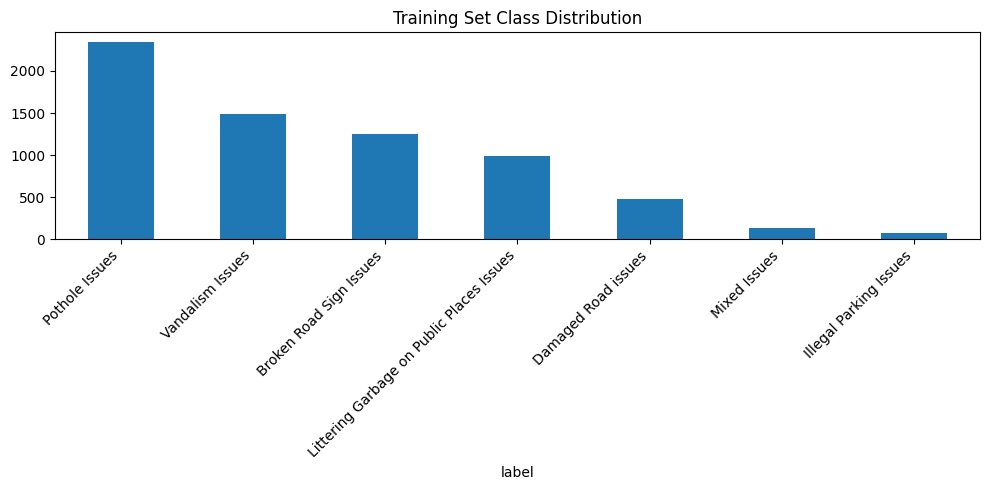

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
train_df['label'].value_counts().plot(kind='bar')
plt.title("Training Set Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<Axes: xlabel='label'>

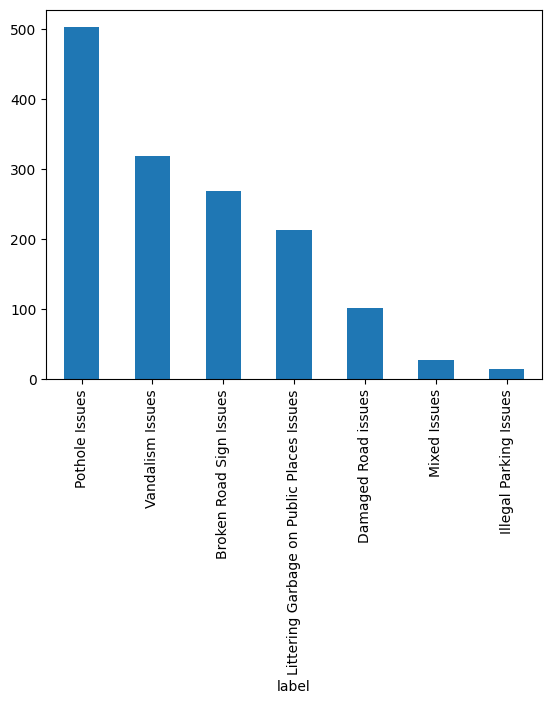

In [44]:
val_df['label'].value_counts().plot(kind='bar')

<Axes: xlabel='label'>

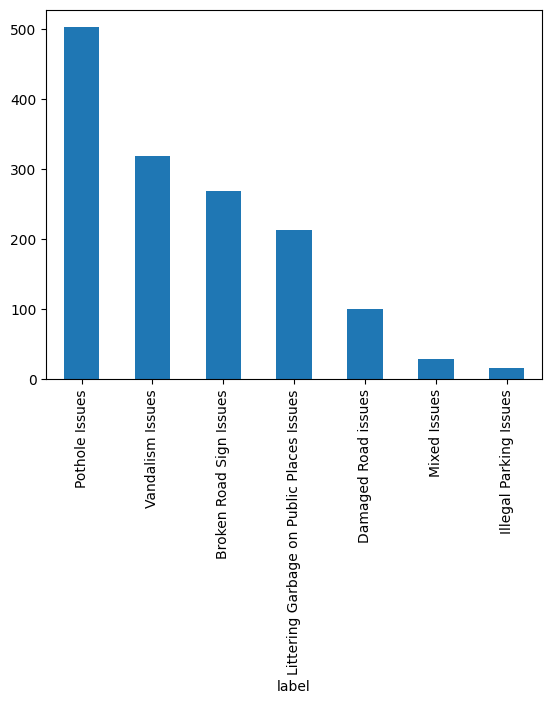

In [45]:
test_df['label'].value_counts().plot(kind='bar')

In [46]:
# ======================================================
# CREATE LABEL → INDEX MAPPING
# ======================================================
unique_labels = sorted(df["label"].unique())
label_to_index = {label: idx for idx, label in enumerate(unique_labels)}
index_to_label = {v: k for k, v in label_to_index.items()}

print("Label Mapping:", label_to_index)

Label Mapping: {'Broken Road Sign Issues': 0, 'Damaged Road issues': 1, 'Illegal Parking Issues': 2, 'Littering Garbage on Public Places Issues': 3, 'Mixed Issues': 4, 'Pothole Issues': 5, 'Vandalism Issues': 6}


In [47]:
# ======================================================
# ADD label_idx COLUMN TO ALL SPLITS
# ======================================================
train_df["label_idx"] = train_df["label"].map(label_to_index)
val_df["label_idx"]   = val_df["label"].map(label_to_index)
test_df["label_idx"]  = test_df["label"].map(label_to_index)

In [48]:
print("\nSample with label_idx:")
print(train_df.head())


Sample with label_idx:
                                               filepath  \
8340  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
1908  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
3714  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
6043  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   
3535  C:\Users\ASUS\Documents\8\comp258_f25\Final_Pr...   

                        label  label_idx  
8340           Pothole Issues          5  
1908         Vandalism Issues          6  
3714  Broken Road Sign Issues          0  
6043   Illegal Parking Issues          2  
3535         Vandalism Issues          6  


In [ ]:
# ======================================================
# Save the original split membership as portable metadata
# ======================================================
from pathlib import Path

OUTPUT_DIR = Path(__file__).resolve().parents[1] / "data" if "__file__" in globals() else Path.cwd().parent / "data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(OUTPUT_DIR / "train_split.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_split.csv", index=False)

In [50]:
print("\n✔ CSV files saved successfully:")
print(os.listdir(OUTPUT_DIR))


✔ CSV files saved successfully:
['test_split.csv', 'train_split.csv', 'val_split.csv']


In [51]:
# ======================================================
# OPTIONAL: QUICK CHECK
# ======================================================
print("\nTrain CSV Columns:", train_df.columns)
print("Val CSV Columns:", val_df.columns)
print("Test CSV Columns:", test_df.columns)



Train CSV Columns: Index(['filepath', 'label', 'label_idx'], dtype='object')
Val CSV Columns: Index(['filepath', 'label', 'label_idx'], dtype='object')
Test CSV Columns: Index(['filepath', 'label', 'label_idx'], dtype='object')


In [52]:
print("\nTotal Images:", len(df))
print("Train / Val / Test =", len(train_df), len(val_df), len(test_df))


Total Images: 9657
Train / Val / Test = 6759 1449 1449
